# Backcasting analysis — cleaned version

This version keeps the final analysis workflow and cached outputs, removes ad-hoc/debug cells, and uses an expanded mainland-Europe extent for the hexagon products so the eastern edge is not clipped at 35°E. Intermediate products are loaded from disk when they already exist. Set `FORCE_RECOMPUTE = True` only if you want to rebuild cached products.

In [1]:
# ------------------------------------------------------------
# Imports and global settings
# ------------------------------------------------------------
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform
from rasterio.warp import reproject

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import Polygon, box
from tqdm.auto import tqdm
from scipy.stats import gaussian_kde

# ------------------------------------------------------------
# Main paths
# ------------------------------------------------------------
old_growth_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif")
old_growth_nodata0_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_nodata0.tif")
prob_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif")
slope_fp = Path("/mnt/eo/EO4Backcasting/_sen_slope_1985_1995/slope_NBR_1985_1995_mosaic.vrt")
undist_fp = Path("/mnt/eo/EFDA_v211/undisturbed_forest.tif")
forest_mask_fp = Path("/mnt/eo/EFDA_v211/forest_landuse_aligned.tif")
genus_fp = Path("/mnt/dss_project/lmandl/_backcasting/data/genus_map_europe.tif")
country_gpkg = Path("/mnt/eo/EO4Backcasting/_data/CNTR_RG_10M_2024_3035.gpkg")

# ------------------------------------------------------------
# Output/cache folders
# ------------------------------------------------------------
out_dir = Path("/mnt/eo/EO4Backcasting/figures")
out_dir.mkdir(parents=True, exist_ok=True)

prob_genus_fig_dir = Path("/mnt/eo/EO4Backcasting/figures/genus_probability")
prob_genus_fig_dir.mkdir(parents=True, exist_ok=True)

cache_dir = Path("/mnt/eo/EO4Backcasting/_analysis_cache")
cache_dir.mkdir(parents=True, exist_ok=True)

aligned_dir = Path("/mnt/eo/EO4Backcasting/_data_aligned")
aligned_dir.mkdir(parents=True, exist_ok=True)

genus_aligned_fp = aligned_dir / "genus_map_europe_aligned_to_probability_30m.tif"

# Cached analysis products
nbr_sample_csv = cache_dir / "nbr_trend_sample_oldgrowth_vs_undisturbed.csv"
genus_counts_csv = cache_dir / "continuously_undisturbed_area_by_genus.csv"
genus_country_csv = cache_dir / "continuously_undisturbed_area_by_genus_country.csv"
genus_share_csv = cache_dir / "continuously_undisturbed_share_by_genus.csv"
country_share_csv = cache_dir / "continuously_undisturbed_share_by_country.csv"
hex_gpkg = cache_dir / "continuously_undisturbed_by_small_clipped_hexagon_lon45.gpkg"
prob_genus_sample_csv = cache_dir / "probability_by_genus_sample.csv"

FORCE_RECOMPUTE = False

# ------------------------------------------------------------
# Analysis settings
# ------------------------------------------------------------
pixel_area_ha = 0.09       # 30 m pixel = 900 m² = 0.09 ha
forest_value = 1
country_name_col = "NAME_ENGL"
exclude_russia = True

# Hexagon settings used in the final version of the original notebook
hex_radius = 17_500
min_forest_area_ha = 500

# Text labels for figures; variable names stay as oldgrowth to avoid rewriting all logic.
forest_label = "continuously undisturbed forest"
forest_label_cap = "Continuously undisturbed forest"

genus_lookup = {
    0: "Larix",
    1: "Picea",
    2: "Pinus",
    3: "Fagus",
    4: "Quercus",
    5: "Other needleleaf",
    6: "Other broadleaf",
    7: "No trees",
}

genus_colors = {
    "Picea": "#2C7FB8",
    "Pinus": "#F28E2B",
    "Fagus": "#59A14F",
    "Quercus": "#E15759",
    "Larix": "#B07AA1",
    "Other broadleaf": "#76B7B2",
    "Other needleleaf": "#EDC948",
    "Other": "#BDBDBD",
}

european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Ireland", "Italy", "Kosovo", "Latvia",
    "Liechtenstein", "Lithuania", "Luxembourg", "Moldova", "Monaco",
    "Montenegro", "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia", "Slovakia",
    "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
    "United Kingdom", "Vatican"
]

# Mainland Europe extent used for clipping country parts and building the hexagon grid.
# The eastern boundary is 45°E to avoid cutting off the eastern edge of the study area.
mainland_bbox_4326 = box(-11, 34, 45, 72)


In [2]:
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def create_hex_grid(bounds, hex_radius, crs):
    """Create a flat-top hexagon grid for a given bounding box."""
    minx, miny, maxx, maxy = bounds
    dx = 1.5 * hex_radius
    dy = np.sqrt(3) * hex_radius

    hexagons = []
    hex_ids = []
    x = minx - 2 * hex_radius
    col = 0
    hex_id = 1

    while x < maxx + 2 * hex_radius:
        y_offset = 0 if col % 2 == 0 else dy / 2
        y = miny - dy

        while y < maxy + dy:
            cy = y + y_offset
            angles = np.deg2rad([0, 60, 120, 180, 240, 300])
            coords = [(x + hex_radius * np.cos(a), cy + hex_radius * np.sin(a)) for a in angles]
            hexagons.append(Polygon(coords))
            hex_ids.append(hex_id)
            hex_id += 1
            y += dy

        x += dx
        col += 1

    return gpd.GeoDataFrame({"hex_id": hex_ids}, geometry=hexagons, crs=crs)


def load_europe_countries(target_crs=None, clip_mainland=False):
    """Load countries, keep European countries, optionally reproject and remove remote/overseas parts."""
    countries = gpd.read_file(country_gpkg)
    countries["country"] = countries[country_name_col].astype(str).str.strip()

    countries = countries[countries["country"].isin(european_countries)].copy()
    if exclude_russia:
        countries = countries[countries["country"] != "Russian Federation"].copy()

    countries = countries[countries.geometry.notna() & ~countries.geometry.is_empty].copy()
    countries["geometry"] = countries.geometry.make_valid()

    if clip_mainland:
        countries_4326 = countries.to_crs(4326)
        parts = countries_4326.explode(index_parts=False).reset_index(drop=True)
        minx, miny, maxx, maxy = mainland_bbox_4326.bounds
        rep = parts.representative_point()
        keep = (
            (rep.x >= minx) & (rep.x <= maxx) &
            (rep.y >= miny) & (rep.y <= maxy)
        )
        parts = parts.loc[keep].copy()
        bbox_gdf = gpd.GeoDataFrame(geometry=[mainland_bbox_4326], crs=4326)
        parts = gpd.clip(parts, bbox_gdf)
        countries = parts.dissolve(by="country", as_index=False)

    if target_crs is not None and countries.crs != target_crs:
        countries = countries.to_crs(target_crs)

    return countries


def ensure_aligned_genus():
    """Load aligned genus raster if present; otherwise create it once."""
    if genus_aligned_fp.exists() and not FORCE_RECOMPUTE:
        print(f"Using existing aligned genus raster: {genus_aligned_fp}")
        return genus_aligned_fp

    print("Creating aligned genus raster...")
    with rasterio.open(prob_fp) as prob_src, rasterio.open(genus_fp) as genus_src:
        profile = prob_src.profile.copy()
        profile.update(
            dtype="uint8",
            count=1,
            nodata=255,
            compress="deflate",
            tiled=True,
            blockxsize=512,
            blockysize=512,
            BIGTIFF="YES",
        )

        with rasterio.open(genus_aligned_fp, "w", **profile) as dst:
            reproject(
                source=rasterio.band(genus_src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=genus_src.transform,
                src_crs=genus_src.crs,
                src_nodata=genus_src.nodata,
                dst_transform=prob_src.transform,
                dst_crs=prob_src.crs,
                dst_nodata=255,
                resampling=Resampling.nearest,
            )

    print(f"Written: {genus_aligned_fp}")
    return genus_aligned_fp


def add_genus_names(df, code_col="genus_code"):
    df = df.copy()
    df["genus"] = df[code_col].map(genus_lookup)
    df["genus"] = df["genus"].fillna("Code " + df[code_col].astype(str))
    return df


## 1. NBR trend comparison

The sample is loaded from cache if available. The expensive random sampling from rasters is only repeated if the CSV is missing or `FORCE_RECOMPUTE = True`.

In [ ]:
# ------------------------------------------------------------
# Load or create random sample for NBR trend comparison
# ------------------------------------------------------------
def sample_nbr_trend(n_samples=50_000, seed=42):
    rng = np.random.default_rng(seed)

    with rasterio.open(old_growth_nodata0_fp) as old_src, \
         rasterio.open(undist_fp) as undist_src, \
         rasterio.open(prob_fp) as prob_src, \
         rasterio.open(slope_fp) as slope_src:

        same_grid = (
            old_src.width == undist_src.width == prob_src.width == slope_src.width and
            old_src.height == undist_src.height == prob_src.height == slope_src.height and
            old_src.transform == undist_src.transform == prob_src.transform == slope_src.transform
        )
        if not same_grid:
            raise ValueError("Input rasters are not on the same grid.")

        total_pixels = old_src.height * old_src.width
        sample_idx = rng.choice(total_pixels, size=n_samples, replace=False)
        rows, cols = np.unravel_index(sample_idx, (old_src.height, old_src.width))
        xs, ys = rasterio.transform.xy(old_src.transform, rows, cols)
        pts = list(zip(xs, ys))

        old_vals = np.array([v[0] for v in tqdm(old_src.sample(pts), total=len(pts), desc="Sampling continuity")])
        undist_vals = np.array([v[0] for v in tqdm(undist_src.sample(pts), total=len(pts), desc="Sampling undisturbed")])
        prob_vals = np.array([v[0] for v in tqdm(prob_src.sample(pts), total=len(pts), desc="Sampling probability")])
        slope_vals = np.array([v[0] for v in tqdm(slope_src.sample(pts), total=len(pts), desc="Sampling NBR slope")])

        valid = np.isfinite(old_vals) & np.isfinite(undist_vals) & np.isfinite(prob_vals) & np.isfinite(slope_vals)
        for src, vals in [(old_src, old_vals), (undist_src, undist_vals), (prob_src, prob_vals), (slope_src, slope_vals)]:
            if src.nodata is not None:
                valid &= vals != src.nodata

    return pd.DataFrame({
        "oldgrowth": old_vals[valid],
        "undisturbed": undist_vals[valid],
        "probability": prob_vals[valid],
        "slope": slope_vals[valid],
    })

if nbr_sample_csv.exists() and not FORCE_RECOMPUTE:
    df_nbr = pd.read_csv(nbr_sample_csv)
    print(f"Loaded cached NBR sample: {nbr_sample_csv}")
else:
    df_nbr = sample_nbr_trend(n_samples=50_000, seed=42)
    df_nbr.to_csv(nbr_sample_csv, index=False)
    print(f"Written: {nbr_sample_csv}")

g1 = df_nbr[df_nbr["oldgrowth"] == 1].copy()
g2 = df_nbr[(df_nbr["undisturbed"] == 1) & (df_nbr["oldgrowth"] != 1)].copy()

print("Sampled valid pixels:", len(df_nbr))
print("Continuously undisturbed pixels:", len(g1))
print("Undisturbed forest excluding continuously undisturbed pixels:", len(g2))


In [ ]:
# ------------------------------------------------------------
# Plot: NBR trend comparison
# ------------------------------------------------------------
plot_df = pd.concat([
    g1.assign(group="Continuously undisturbed forest"),
    g2.assign(group="Other undisturbed forest"),
])

fig, ax = plt.subplots(figsize=(6.2, 5.2))

ax.boxplot(
    [
        plot_df.loc[plot_df["group"] == "Continuously undisturbed forest", "slope"].dropna(),
        plot_df.loc[plot_df["group"] == "Other undisturbed forest", "slope"].dropna(),
    ],
    tick_labels=["Continuously\nundisturbed forest", "Other undisturbed\nforest"],
    showfliers=False,
    patch_artist=True,
    medianprops=dict(linewidth=2.2, color="black"),
    boxprops=dict(linewidth=1.4),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

ax.axhline(0, linestyle="--", linewidth=1.2, color="grey", alpha=0.8)
ax.set_ylabel("NBR slope 1985–1995", fontsize=12)
ax.set_title("NBR trend comparison", fontsize=14, pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_png = out_dir / "nbr_trend_boxplot.png"
out_svg = out_dir / "nbr_trend_boxplot.svg"
fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)


## 2. Tree genus composition

The raster counting is cached as tables. Existing CSV files are loaded directly.

In [4]:
# ------------------------------------------------------------
# Load or compute genus area within continuously undisturbed forest
# ------------------------------------------------------------
def count_genus_area():
    counter = Counter()

    with rasterio.open(old_growth_fp) as old_src, rasterio.open(genus_fp) as genus_src:
        with WarpedVRT(
            genus_src,
            crs=old_src.crs,
            transform=old_src.transform,
            width=old_src.width,
            height=old_src.height,
            resampling=Resampling.nearest,
            src_nodata=genus_src.nodata,
            nodata=255,
        ) as genus_vrt:
            windows = [window for _, window in old_src.block_windows(1)]

            for window in tqdm(windows, desc="Counting genus within continuously undisturbed pixels"):
                old = old_src.read(1, window=window)
                if not np.any(old == 1):
                    continue

                genus = genus_vrt.read(1, window=window)
                valid = (old == 1) & (genus != 255) & np.isfinite(genus)
                vals = genus[valid]

                if vals.size > 0:
                    unique, counts = np.unique(vals.astype(np.int32), return_counts=True)
                    counter.update(dict(zip(unique, counts)))

    df = pd.DataFrame(counter.items(), columns=["genus_code", "n_pixels"])
    df["area_ha"] = df["n_pixels"] * pixel_area_ha
    df["percent"] = df["n_pixels"] / df["n_pixels"].sum() * 100
    df = add_genus_names(df)
    df = df.sort_values("area_ha", ascending=False)
    return df

if genus_counts_csv.exists() and not FORCE_RECOMPUTE:
    df_counts = pd.read_csv(genus_counts_csv)
    print(f"Loaded cached genus counts: {genus_counts_csv}")
else:
    df_counts = count_genus_area()
    df_counts.to_csv(genus_counts_csv, index=False)
    print(f"Written: {genus_counts_csv}")

display(df_counts.head(20))


Loaded cached genus counts: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_area_by_genus.csv


,genus_code,n_pixels,area_ha,percent,genus
0,1,20204726,1818425.34,69.129702,Picea
1,2,6900251,621022.59,23.608946,Pinus
2,6,783092,70478.28,2.679320,Other broadleaf
3,5,491674,44250.66,1.682244,Other needleleaf
4,7,396445,35680.05,1.356421,No trees
5,3,319878,28789.02,1.094450,Fagus
6,4,75638,6807.42,0.258793,Quercus
7,0,55568,5001.12,0.190124,Larix


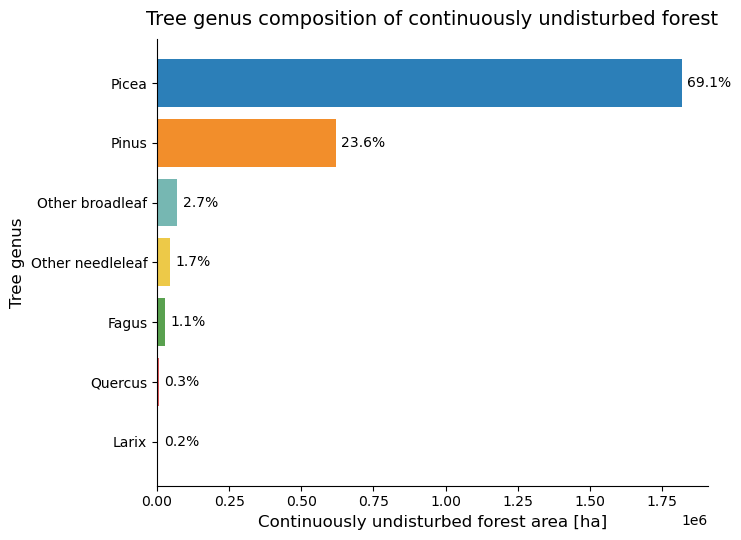

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_genus_barplot.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_genus_barplot.svg


In [5]:
# ------------------------------------------------------------
# Plot: genus composition of continuously undisturbed forest
# ------------------------------------------------------------
plot_df = df_counts[df_counts["genus"] != "No trees"].copy()
plot_df = plot_df.sort_values("area_ha", ascending=True)
plot_df["color"] = plot_df["genus"].map(genus_colors).fillna("#BDBDBD")

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.barh(plot_df["genus"], plot_df["area_ha"], color=plot_df["color"], edgecolor="none")
ax.set_xlabel(f"{forest_label_cap} area [ha]", fontsize=12)
ax.set_ylabel("Tree genus", fontsize=12)
ax.set_title(f"Tree genus composition of {forest_label}", fontsize=14, pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

xmax = plot_df["area_ha"].max()
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["area_ha"] + xmax * 0.01, i, f'{row["percent"]:.1f}%', va="center", fontsize=10)

plt.tight_layout()

out_png = out_dir / "old_growth_genus_barplot.png"
out_svg = out_dir / "old_growth_genus_barplot.svg"
fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)


In [6]:
# ------------------------------------------------------------
# Load or compute total genus area and continuously undisturbed share by genus
# ------------------------------------------------------------
def count_total_and_undisturbed_genus_area():
    counter_total = Counter()
    counter_oldgrowth = Counter()

    with rasterio.open(old_growth_fp) as old_src, rasterio.open(genus_fp) as genus_src:
        with WarpedVRT(
            genus_src,
            crs=old_src.crs,
            transform=old_src.transform,
            width=old_src.width,
            height=old_src.height,
            resampling=Resampling.nearest,
            src_nodata=genus_src.nodata,
            nodata=255,
        ) as genus_vrt:
            windows = [window for _, window in old_src.block_windows(1)]

            for window in tqdm(windows, desc="Counting total and continuously undisturbed genus area"):
                old = old_src.read(1, window=window)
                genus = genus_vrt.read(1, window=window)

                valid_genus = (genus != 255) & np.isfinite(genus) & (genus != 7)
                vals_total = genus[valid_genus].astype(np.int16)
                if vals_total.size > 0:
                    unique, counts = np.unique(vals_total, return_counts=True)
                    counter_total.update(dict(zip(unique, counts)))

                vals_old = genus[valid_genus & (old == 1)].astype(np.int16)
                if vals_old.size > 0:
                    unique, counts = np.unique(vals_old, return_counts=True)
                    counter_oldgrowth.update(dict(zip(unique, counts)))

    df_total = pd.DataFrame(counter_total.items(), columns=["genus_code", "total_pixels"])
    df_old = pd.DataFrame(counter_oldgrowth.items(), columns=["genus_code", "oldgrowth_pixels"])
    df = df_total.merge(df_old, on="genus_code", how="left")
    df["oldgrowth_pixels"] = df["oldgrowth_pixels"].fillna(0)
    df["total_area_ha"] = df["total_pixels"] * pixel_area_ha
    df["oldgrowth_area_ha"] = df["oldgrowth_pixels"] * pixel_area_ha
    df["oldgrowth_share_percent"] = df["oldgrowth_area_ha"] / df["total_area_ha"] * 100
    df = add_genus_names(df)
    return df.sort_values("oldgrowth_share_percent", ascending=False)

if genus_share_csv.exists() and not FORCE_RECOMPUTE:
    df_genus_share = pd.read_csv(genus_share_csv)
    print(f"Loaded cached genus share table: {genus_share_csv}")
else:
    df_genus_share = count_total_and_undisturbed_genus_area()
    df_genus_share.to_csv(genus_share_csv, index=False)
    print(f"Written: {genus_share_csv}")

display(df_genus_share)


Loaded cached genus share table: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_share_by_genus.csv


,genus_code,total_pixels,oldgrowth_pixels,total_area_ha,oldgrowth_area_ha,oldgrowth_share_percent,genus
0,1,478199729,20204726,43037975.61,1818425.34,4.225165,Picea
1,5,38353309,491674,3451797.81,44250.66,1.281960,Other needleleaf
2,2,674970677,6900251,60747360.93,621022.59,1.022304,Pinus
3,0,13422735,55568,1208046.15,5001.12,0.413984,Larix
4,3,203003367,319878,18270303.03,28789.02,0.157573,Fagus
5,6,766017671,783092,68941590.39,70478.28,0.102229,Other broadleaf
6,4,324662867,75638,29219658.03,6807.42,0.023297,Quercus


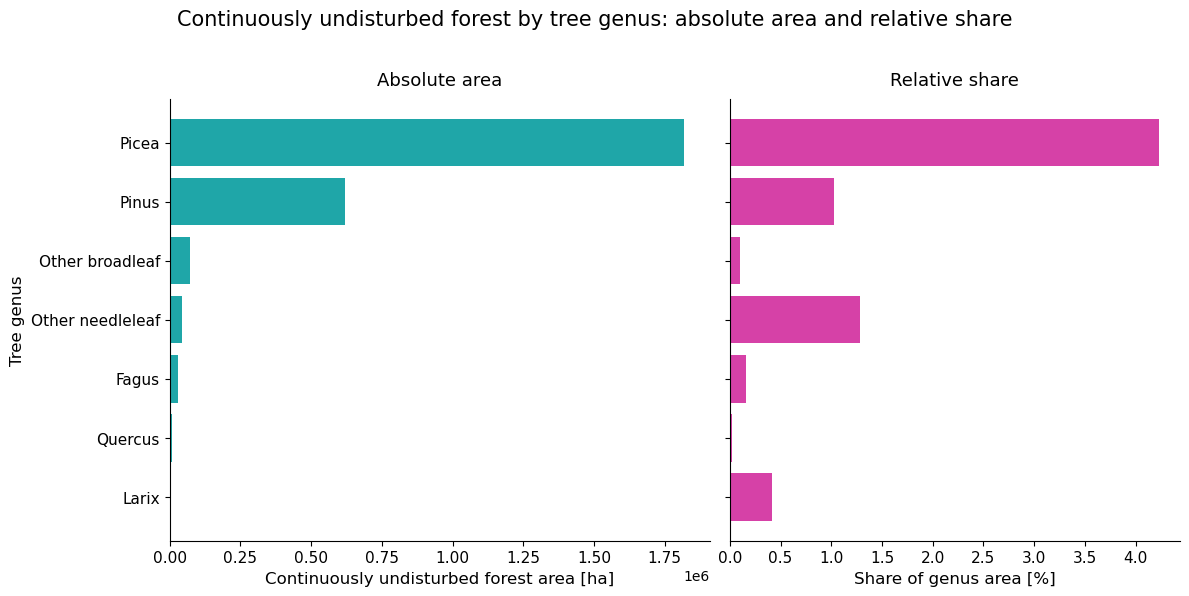

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_and_relative_by_genus.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_and_relative_by_genus.svg


In [7]:
# ------------------------------------------------------------
# Plot: absolute area and relative share by genus
# ------------------------------------------------------------
plot_df = df_genus_share.sort_values("oldgrowth_area_ha", ascending=True).copy()

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5.8),
    sharey=True,
    gridspec_kw={"width_ratios": [1.2, 1]},
)

axes[0].barh(plot_df["genus"], plot_df["oldgrowth_area_ha"], color="#1FA6A8")
axes[0].set_xlabel(f"{forest_label_cap} area [ha]", fontsize=12)
axes[0].set_ylabel("Tree genus", fontsize=12)
axes[0].set_title("Absolute area", fontsize=13, pad=10)

axes[1].barh(plot_df["genus"], plot_df["oldgrowth_share_percent"], color="#D641A7")
axes[1].set_xlabel("Share of genus area [%]", fontsize=12)
axes[1].set_title("Relative share", fontsize=13, pad=10)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=11)

fig.suptitle(f"{forest_label_cap} by tree genus: absolute area and relative share", fontsize=15, y=1.02)
plt.tight_layout()

out_png = out_dir / "old_growth_absolute_and_relative_by_genus.png"
out_svg = out_dir / "old_growth_absolute_and_relative_by_genus.svg"
fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)


## 3. Country-level area and share

Country-by-genus and country forest-share tables are cached, so the expensive block-wise rasterization is not repeated unless needed.

In [8]:
# ------------------------------------------------------------
# Load or compute country x genus table
# ------------------------------------------------------------
def count_genus_by_country():
    with rasterio.open(old_growth_fp) as old_src:
        countries = load_europe_countries(target_crs=old_src.crs, clip_mainland=False)

    countries = countries.reset_index(drop=True)
    countries["country_code"] = np.arange(1, len(countries) + 1).astype(np.int32)
    country_lookup = dict(zip(countries["country_code"], countries["country"]))
    sindex = countries.sindex
    counter = Counter()

    with rasterio.open(old_growth_fp) as old_src, rasterio.open(genus_fp) as genus_src:
        with WarpedVRT(
            genus_src,
            crs=old_src.crs,
            transform=old_src.transform,
            width=old_src.width,
            height=old_src.height,
            resampling=Resampling.nearest,
            src_nodata=genus_src.nodata,
            nodata=255,
        ) as genus_vrt:
            windows = [window for _, window in old_src.block_windows(1)]

            for window in tqdm(windows, desc="Counting genus and country"):
                old = old_src.read(1, window=window)
                if not np.any(old == 1):
                    continue

                genus = genus_vrt.read(1, window=window)
                b = window_bounds(window, old_src.transform)
                block_geom = box(*b)

                candidate_idx = list(sindex.intersection(block_geom.bounds))
                if not candidate_idx:
                    continue

                countries_block = countries.iloc[candidate_idx].copy()
                countries_block = countries_block[countries_block.intersects(block_geom)]
                if countries_block.empty:
                    continue

                country_block = rasterize(
                    shapes=zip(countries_block.geometry, countries_block["country_code"]),
                    out_shape=old.shape,
                    transform=window_transform(window, old_src.transform),
                    fill=0,
                    dtype="int32",
                    all_touched=False,
                )

                valid = (old == 1) & (genus != 255) & (genus != 7) & (country_block != 0) & np.isfinite(genus)
                genus_vals = genus[valid].astype(np.int16)
                country_vals = country_block[valid].astype(np.int32)

                if genus_vals.size > 0:
                    counter.update(zip(genus_vals, country_vals))

    df = pd.DataFrame([(g, c, n) for (g, c), n in counter.items()], columns=["genus_code", "country_code", "n_pixels"])
    df["area_ha"] = df["n_pixels"] * pixel_area_ha
    df = add_genus_names(df)
    df["country"] = df["country_code"].map(country_lookup).fillna("Unknown country")
    return df.sort_values("area_ha", ascending=False)

if genus_country_csv.exists() and not FORCE_RECOMPUTE:
    df_gc = pd.read_csv(genus_country_csv)
    print(f"Loaded cached country-genus table: {genus_country_csv}")
else:
    df_gc = count_genus_by_country()
    df_gc.to_csv(genus_country_csv, index=False)
    print(f"Written: {genus_country_csv}")

display(df_gc.head(20))


Loaded cached country-genus table: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_area_by_genus_country.csv


,genus_code,country_code,n_pixels,area_ha,genus,country
0,1,30,3691596,332243.64,Picea,Sweden
1,1,12,3499630,314966.70,Picea,Germany
2,2,33,2279209,205128.81,Pinus,Poland
3,1,11,1902938,171264.42,Picea,Czechia
4,1,35,1813235,163191.15,Picea,Romania
5,1,8,1727891,155510.19,Picea,Finland
6,1,3,1468063,132125.67,Picea,Austria
7,2,30,1448767,130389.03,Pinus,Sweden
8,1,33,1182918,106462.62,Picea,Poland
9,1,32,1107036,99633.24,Picea,Norway


In [9]:
# ------------------------------------------------------------
# Load or compute share of continuously undisturbed forest by country
# ------------------------------------------------------------
def count_country_forest_share():
    with rasterio.open(old_growth_fp) as old_src:
        countries = load_europe_countries(target_crs=old_src.crs, clip_mainland=False)

    countries = countries.reset_index(drop=True)
    countries["country_code"] = np.arange(1, len(countries) + 1).astype(np.int32)
    country_lookup = dict(zip(countries["country_code"], countries["country"]))
    sindex = countries.sindex

    forest_counter = Counter()
    oldgrowth_counter = Counter()

    with rasterio.open(old_growth_fp) as old_src, rasterio.open(forest_mask_fp) as forest_src:
        with WarpedVRT(
            forest_src,
            crs=old_src.crs,
            transform=old_src.transform,
            width=old_src.width,
            height=old_src.height,
            resampling=Resampling.nearest,
            src_nodata=forest_src.nodata,
            nodata=0,
        ) as forest_vrt:
            windows = [window for _, window in old_src.block_windows(1)]

            for window in tqdm(windows, desc="Counting forest and continuously undisturbed area by country"):
                old = old_src.read(1, window=window)
                forest = forest_vrt.read(1, window=window)

                if not (np.any(forest == forest_value) or np.any(old == 1)):
                    continue

                b = window_bounds(window, old_src.transform)
                block_geom = box(*b)
                candidate_idx = list(sindex.intersection(block_geom.bounds))
                if not candidate_idx:
                    continue

                countries_block = countries.iloc[candidate_idx].copy()
                countries_block = countries_block[countries_block.intersects(block_geom)]
                if countries_block.empty:
                    continue

                country_block = rasterize(
                    shapes=zip(countries_block.geometry, countries_block["country_code"]),
                    out_shape=old.shape,
                    transform=window_transform(window, old_src.transform),
                    fill=0,
                    dtype="int32",
                    all_touched=False,
                )

                valid_country = country_block != 0
                forest_ids = country_block[valid_country & (forest == forest_value)].astype(np.int32)
                old_ids = country_block[valid_country & (forest == forest_value) & (old == 1)].astype(np.int32)

                if forest_ids.size > 0:
                    unique, counts = np.unique(forest_ids, return_counts=True)
                    forest_counter.update(dict(zip(unique, counts)))

                if old_ids.size > 0:
                    unique, counts = np.unique(old_ids, return_counts=True)
                    oldgrowth_counter.update(dict(zip(unique, counts)))

    df_forest = pd.DataFrame(forest_counter.items(), columns=["country_code", "forest_pixels"])
    df_old = pd.DataFrame(oldgrowth_counter.items(), columns=["country_code", "oldgrowth_pixels"])
    df = df_forest.merge(df_old, on="country_code", how="left")
    df["oldgrowth_pixels"] = df["oldgrowth_pixels"].fillna(0)
    df["country"] = df["country_code"].map(country_lookup)
    df["forest_area_ha"] = df["forest_pixels"] * pixel_area_ha
    df["oldgrowth_area_ha"] = df["oldgrowth_pixels"] * pixel_area_ha
    df["oldgrowth_share_percent"] = df["oldgrowth_area_ha"] / df["forest_area_ha"] * 100
    return df.sort_values("oldgrowth_share_percent", ascending=False)

if country_share_csv.exists() and not FORCE_RECOMPUTE:
    df_country_share = pd.read_csv(country_share_csv)
    print(f"Loaded cached country share table: {country_share_csv}")
else:
    df_country_share = count_country_forest_share()
    df_country_share.to_csv(country_share_csv, index=False)
    print(f"Written: {country_share_csv}")

display(df_country_share.head(20))


Loaded cached country share table: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_share_by_country.csv


,country_code,forest_pixels,oldgrowth_pixels,country,forest_area_ha,oldgrowth_area_ha,oldgrowth_share_percent
0,11,36306141,2235458.0,Czechia,3267552.69,201191.22,6.157245
1,12,135784176,5084944.0,Germany,12220575.84,457644.96,3.744872
2,3,49986108,1550939.0,Austria,4498749.72,139584.51,3.102740
3,33,123880266,3712089.0,Poland,11149223.94,334088.01,2.996514
4,14,31179762,878894.0,Estonia,2806178.58,79100.46,2.818796
5,35,98257774,1904590.0,Romania,8843199.66,171413.10,1.938361
6,24,42973013,715893.0,Latvia,3867571.17,64430.37,1.665913
7,4,33448993,548789.0,Bosnia and Herzegovina,3010409.37,49391.01,1.640674
8,30,340033918,5301155.0,Sweden,30603052.62,477103.95,1.559008
9,36,14824841,196501.0,Slovenia,1334235.69,17685.09,1.325485


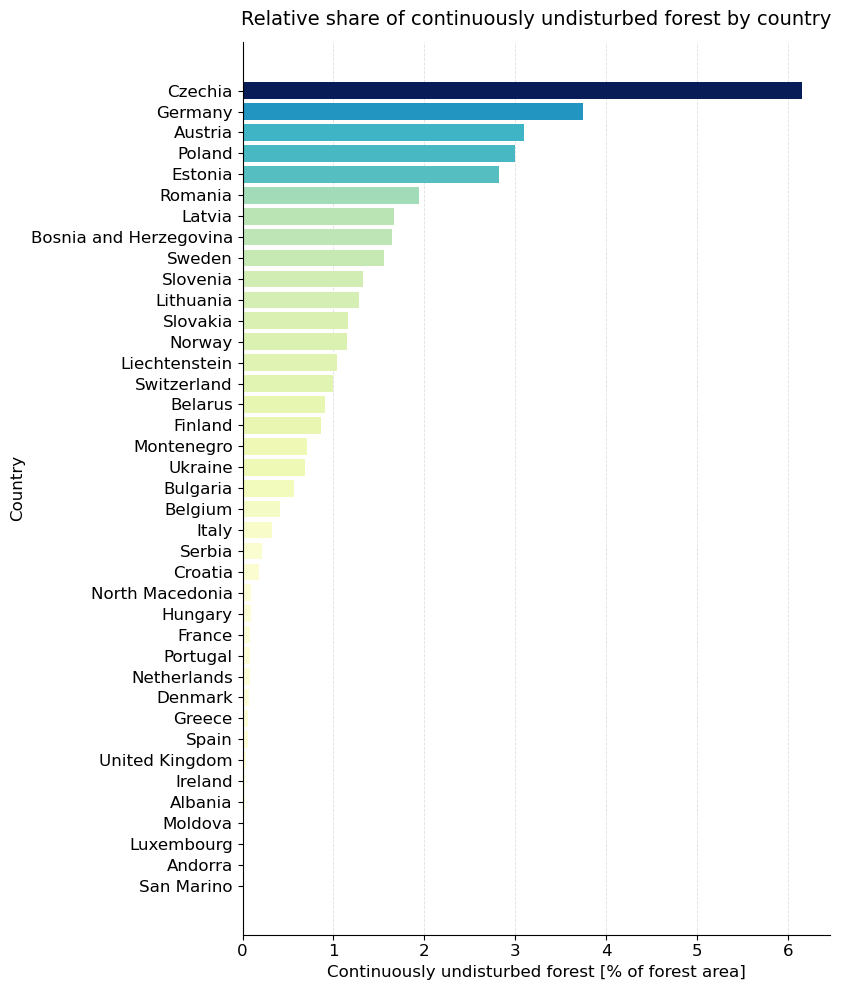

Saved barplot PNG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_barplot_matched_colors.png
Saved barplot SVG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_barplot_matched_colors.svg


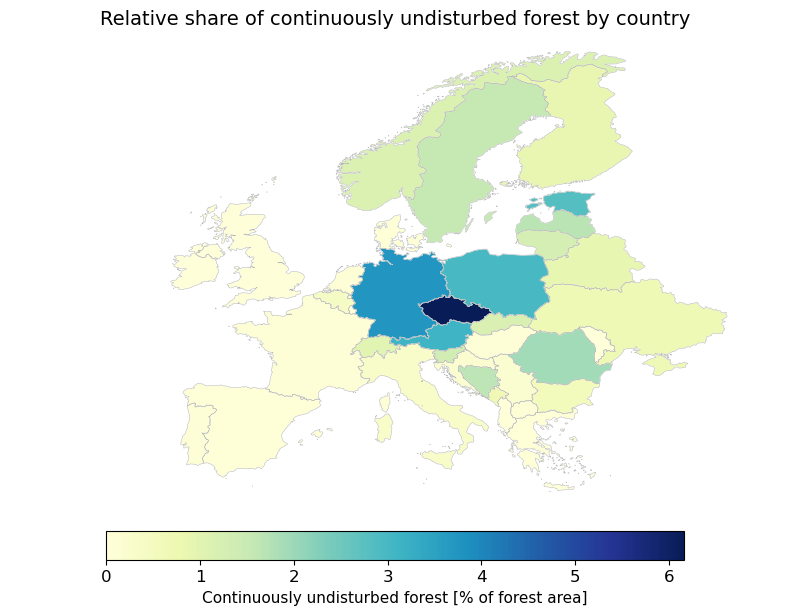

Saved map PNG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_map_matched_colors.png
Saved map SVG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_map_matched_colors.svg


In [10]:
# ------------------------------------------------------------
# Plot: country share barplot and map
# ------------------------------------------------------------
cmap = plt.get_cmap("YlGnBu")
vmin = 0
vmax = df_country_share["oldgrowth_share_percent"].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

df_country_share["plot_color"] = df_country_share["oldgrowth_share_percent"].apply(lambda x: cmap(norm(x)))

country_bar = df_country_share.sort_values("oldgrowth_share_percent", ascending=True).copy()

fig, ax = plt.subplots(figsize=(8.5, 10))
ax.barh(country_bar["country"], country_bar["oldgrowth_share_percent"], color=country_bar["plot_color"])
ax.set_xlabel(f"{forest_label_cap} [% of forest area]", fontsize=12)
ax.set_ylabel("Country", fontsize=12)
ax.set_title(f"Relative share of {forest_label} by country", fontsize=14, pad=12)
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()

out_png_bar = out_dir / "old_growth_share_of_forest_by_country_barplot_matched_colors.png"
out_svg_bar = out_dir / "old_growth_share_of_forest_by_country_barplot_matched_colors.svg"
fig.savefig(out_png_bar, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_bar, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved barplot PNG:", out_png_bar)
print("Saved barplot SVG:", out_svg_bar)

# Map
with rasterio.open(old_growth_fp) as src:
    countries_map = load_europe_countries(target_crs=src.crs, clip_mainland=False)

countries_map = countries_map.merge(
    df_country_share[["country", "oldgrowth_share_percent", "plot_color"]],
    on="country",
    how="left",
)
countries_map["oldgrowth_share_percent"] = countries_map["oldgrowth_share_percent"].fillna(0)
countries_map["plot_color"] = countries_map["plot_color"].fillna("#eeeeee")
countries_map = countries_map.to_crs(4326)

fig, ax = plt.subplots(figsize=(8, 8))
countries_map.plot(color=countries_map["plot_color"], linewidth=0.5, edgecolor="white", ax=ax)
countries_map.boundary.plot(ax=ax, color="0.7", linewidth=0.35)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.75, fraction=0.045, pad=0.04)
cbar.set_label(f"{forest_label_cap} [% of forest area]", fontsize=11)
cbar.ax.tick_params(labelsize=12)

ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)
ax.set_title(f"Relative share of {forest_label} by country", fontsize=14, pad=12)
ax.set_axis_off()
plt.tight_layout()

out_png_map = out_dir / "old_growth_share_of_forest_by_country_map_matched_colors.png"
out_svg_map = out_dir / "old_growth_share_of_forest_by_country_map_matched_colors.svg"
fig.savefig(out_png_map, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_map, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved map PNG:", out_png_map)
print("Saved map SVG:", out_svg_map)


## 4. Hexagon maps

This replaces the repeated hexagon workflows with one cached product. If the GeoPackage exists, it is loaded directly; otherwise, the clipped hexagons and raster counts are computed once and written to disk.

In [12]:
# ------------------------------------------------------------
# Load or compute clipped hexagon summary
# Existing GPKG is renamed before writing a new one
# ------------------------------------------------------------

from pathlib import Path
from datetime import datetime


def compute_hexagon_summary():
    with rasterio.open(old_growth_fp) as old_src:
        countries_eur = load_europe_countries(
            target_crs=old_src.crs,
            clip_mainland=True
        )

    europe_geom = countries_eur.geometry.union_all()
    europe_bounds = countries_eur.total_bounds

    hexes = create_hex_grid(
        bounds=europe_bounds,
        hex_radius=hex_radius,
        crs=countries_eur.crs
    )

    hexes = hexes[hexes.intersects(europe_geom)].copy()

    europe_clip = gpd.GeoDataFrame(
        geometry=[europe_geom],
        crs=countries_eur.crs
    )

    hexes = gpd.clip(hexes, europe_clip)
    hexes = hexes[hexes.geometry.notna() & ~hexes.geometry.is_empty].copy()
    hexes["geometry"] = hexes.geometry.make_valid()
    hexes = hexes.reset_index(drop=True)
    hexes["hex_id"] = np.arange(1, len(hexes) + 1).astype(np.int32)

    print("Number of clipped hexagons:", len(hexes))

    hex_sindex = hexes.sindex
    forest_counter = Counter()
    oldgrowth_counter = Counter()

    with rasterio.open(old_growth_fp) as old_src, rasterio.open(forest_mask_fp) as forest_src:
        with WarpedVRT(
            forest_src,
            crs=old_src.crs,
            transform=old_src.transform,
            width=old_src.width,
            height=old_src.height,
            resampling=Resampling.nearest,
            src_nodata=forest_src.nodata,
            nodata=0,
        ) as forest_vrt:

            windows = [window for _, window in old_src.block_windows(1)]

            for window in tqdm(
                windows,
                desc="Counting forest and continuously undisturbed area by clipped hexagon"
            ):
                old = old_src.read(1, window=window)
                forest = forest_vrt.read(1, window=window)

                if not (np.any(forest == forest_value) or np.any(old == 1)):
                    continue

                b = window_bounds(window, old_src.transform)
                block_geom = box(*b)

                candidate_idx = list(hex_sindex.intersection(block_geom.bounds))
                if not candidate_idx:
                    continue

                hex_block = hexes.iloc[candidate_idx].copy()
                hex_block = hex_block[hex_block.intersects(block_geom)]

                if hex_block.empty:
                    continue

                hex_raster = rasterize(
                    shapes=zip(hex_block.geometry, hex_block["hex_id"]),
                    out_shape=old.shape,
                    transform=window_transform(window, old_src.transform),
                    fill=0,
                    dtype="int32",
                    all_touched=False,
                )

                valid_hex = hex_raster != 0
                valid_forest = valid_hex & (forest == forest_value)

                forest_ids = hex_raster[valid_forest].astype(np.int32)
                old_ids = hex_raster[valid_forest & (old == 1)].astype(np.int32)

                if forest_ids.size > 0:
                    unique, counts = np.unique(forest_ids, return_counts=True)
                    forest_counter.update(dict(zip(unique, counts)))

                if old_ids.size > 0:
                    unique, counts = np.unique(old_ids, return_counts=True)
                    oldgrowth_counter.update(dict(zip(unique, counts)))

    df_forest_hex = pd.DataFrame(
        forest_counter.items(),
        columns=["hex_id", "forest_pixels"]
    )

    df_old_hex = pd.DataFrame(
        oldgrowth_counter.items(),
        columns=["hex_id", "oldgrowth_pixels"]
    )

    df_hex = df_forest_hex.merge(
        df_old_hex,
        on="hex_id",
        how="left"
    )

    df_hex["oldgrowth_pixels"] = df_hex["oldgrowth_pixels"].fillna(0)

    df_hex["forest_area_ha"] = (
        df_hex["forest_pixels"] * pixel_area_ha
    )

    df_hex["oldgrowth_area_ha"] = (
        df_hex["oldgrowth_pixels"] * pixel_area_ha
    )

    df_hex["oldgrowth_share_percent"] = (
        df_hex["oldgrowth_area_ha"] /
        df_hex["forest_area_ha"] *
        100
    )

    hexes_plot = hexes.merge(
        df_hex,
        on="hex_id",
        how="left"
    )

    hexes_plot = hexes_plot[
        hexes_plot["forest_area_ha"].notna() &
        (hexes_plot["forest_area_ha"] >= min_forest_area_ha)
    ].copy()

    return hexes_plot, countries_eur


def cache_is_stale_or_clipped(gdf, min_expected_max_lon=40):
    """
    Return True if cached hexagons still look clipped at the old 35°E extent.
    """
    max_lon = gdf.to_crs(4326).total_bounds[2]
    return max_lon < min_expected_max_lon


def backup_existing_gpkg(path):
    """
    Rename an existing GeoPackage with a timestamp.
    Possible SQLite sidecar files are renamed as well.
    """
    path = Path(path)

    if not path.exists():
        return

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    backup_path = path.with_name(
        f"{path.stem}_backup_{timestamp}{path.suffix}"
    )

    path.rename(backup_path)
    print(f"Existing GPKG renamed to: {backup_path}")

    for suffix in ["-wal", "-shm", "-journal"]:
        sidecar = Path(str(path) + suffix)

        if sidecar.exists():
            sidecar_backup = path.with_name(
                f"{path.stem}_backup_{timestamp}{path.suffix}{suffix}"
            )
            sidecar.rename(sidecar_backup)
            print(f"Existing sidecar renamed to: {sidecar_backup}")


def write_hexes_gpkg_with_backup(gdf, path, layer="hexes"):
    """
    Write hexagon GeoDataFrame to GPKG.
    If the target GPKG already exists, it is renamed first.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    gdf_out = gdf.copy()
    gdf_out = gdf_out[
        gdf_out.geometry.notna() &
        ~gdf_out.geometry.is_empty
    ].copy()

    gdf_out["geometry"] = gdf_out.geometry.make_valid()

    backup_existing_gpkg(path)

    gdf_out.to_file(
        path,
        layer=layer,
        driver="GPKG"
    )

    print(f"Written: {path}")


# ------------------------------------------------------------
# Main cache logic
# ------------------------------------------------------------

if hex_gpkg.exists() and not FORCE_RECOMPUTE:
    hexes_plot = gpd.read_file(hex_gpkg, layer="hexes")

    if cache_is_stale_or_clipped(hexes_plot):
        print(
            f"Cached hexagon product appears clipped at "
            f"{hexes_plot.to_crs(4326).total_bounds[2]:.2f}°E. "
            f"Recomputing: {hex_gpkg}"
        )

        hexes_plot, countries_eur = compute_hexagon_summary()

        write_hexes_gpkg_with_backup(
            hexes_plot,
            hex_gpkg,
            layer="hexes"
        )

    else:
        with rasterio.open(old_growth_fp) as src:
            countries_eur = load_europe_countries(
                target_crs=src.crs,
                clip_mainland=True
            )

        print(f"Loaded cached hexagon product: {hex_gpkg}")

else:
    hexes_plot, countries_eur = compute_hexagon_summary()

    write_hexes_gpkg_with_backup(
        hexes_plot,
        hex_gpkg,
        layer="hexes"
    )


print("Hexagons with sufficient forest:", len(hexes_plot))
print("Hex bounds EPSG:4326:", hexes_plot.to_crs(4326).total_bounds)
print("Country bounds EPSG:4326:", countries_eur.to_crs(4326).total_bounds)

display(
    hexes_plot[
        [
            "hex_id",
            "forest_area_ha",
            "oldgrowth_area_ha",
            "oldgrowth_share_percent"
        ]
    ].head()
)

DataSourceError: '/mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_by_small_clipped_hexagon_lon45.gpkg' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.

In [ ]:
# ------------------------------------------------------------
# Plot: relative continuously undisturbed forest share by hexagon
# Values < 0.1% in very light grey
# Linear color scale fixed to 0–7%; values above the cap use the darkest color
# Light grey polygon borders + country boundaries
# ------------------------------------------------------------

rel_col = "oldgrowth_share_percent"
low_threshold = 0.1

# Keep only valid relative-share values
hexes_rel = hexes_plot[hexes_plot[rel_col].notna()].copy()

# Split low and plotted values
hexes_low = hexes_rel[hexes_rel[rel_col] < low_threshold].copy()
hexes_high = hexes_rel[hexes_rel[rel_col] >= low_threshold].copy()

print(hexes_rel[rel_col].describe())
print(f"Hexagons with {rel_col} < {low_threshold}: {len(hexes_low)}")
print(f"Hexagons with {rel_col} >= {low_threshold}: {len(hexes_high)}")

# Linear color scaling
vmin = 0
vmax = 7
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap = plt.get_cmap("YlGnBu").copy()
cmap.set_bad(alpha=0)

# Ensure countries are in the same CRS as the hexagons
countries_plot = countries_eur.to_crs(hexes_rel.crs)

fig, ax = plt.subplots(figsize=(10, 10))

# Values below threshold: very light grey
if len(hexes_low) > 0:
    hexes_low.plot(
        ax=ax,
        color="0.94",
        linewidth=0.18,
        edgecolor="0.82",
        alpha=1.0,
        zorder=1,
    )

# Values above threshold: linear color scale
if len(hexes_high) > 0:
    hexes_high.plot(
        column=rel_col,
        ax=ax,
        cmap=cmap,
        norm=norm,
        linewidth=0.18,
        edgecolor="0.82",
        alpha=1.0,
        zorder=2,
    )

# Country boundaries
countries_plot.boundary.plot(
    ax=ax,
    linewidth=0.40,
    edgecolor="0.30",
    alpha=0.85,
    zorder=10,
)

# Continuous colorbar, plotted with linear 0–7% scaling.
# The upper label indicates that values above the plotted cap exist.
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.72,
    pad=0.02,
    ticks=np.arange(0, 8, 1),
    extend="max",
)

cbar.ax.set_yticklabels(["0", "1", "2", "3", "4", "5", "6", ">10"])
cbar.set_label("Continuously undisturbed forest area (%)", fontsize=12)
cbar.ax.tick_params(labelsize=12)
cbar.outline.set_linewidth(0.6)

# Legend entry for grey threshold class
legend_handles = [
    Patch(
        facecolor="0.94",
        edgecolor="0.82",
        label=f"< {low_threshold}%",
    )
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    framealpha=0.9,
    fontsize=11,
)

ax.set_axis_off()

out_png_rel = out_dir / "oldgrowth_share_hexagons_linear_0_7_lowvals_lt_0_1_grey_countries_lon45.png"
out_svg_rel = out_dir / "oldgrowth_share_hexagons_linear_0_7_lowvals_lt_0_1_grey_countries_lon45.svg"

fig.savefig(out_png_rel, dpi=300, bbox_inches="tight", pad_inches=0.02, facecolor="white")
fig.savefig(out_svg_rel, bbox_inches="tight", pad_inches=0.02, facecolor="white")

plt.show()

print("Saved relative hex map PNG:", out_png_rel)
print("Saved relative hex map SVG:", out_svg_rel)


## 5. Country pie map and simple genus summary

These plots reuse the cached country-by-genus table, so no raster counting is repeated.

In [ ]:
# ------------------------------------------------------------
# Plot: country pie map of genus composition
# ------------------------------------------------------------
top_n_genera = 5
min_size = 0.2
max_size = 0.5

# Prepare data
plot_gc = df_gc.copy()
plot_gc["country"] = plot_gc["country"].astype(str).str.strip()
plot_gc["genus"] = plot_gc["genus"].astype(str).str.strip()
plot_gc = plot_gc[plot_gc["genus"] != "No trees"].copy()
if exclude_russia:
    plot_gc = plot_gc[plot_gc["country"] != "Russian Federation"].copy()

top_genera = (
    plot_gc.groupby("genus")["area_ha"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n_genera)
    .index
    .tolist()
)
plot_gc["genus_plot"] = np.where(plot_gc["genus"].isin(top_genera), plot_gc["genus"], "Other")

df_country_genus = plot_gc.groupby(["country", "genus_plot"], as_index=False)["area_ha"].sum()
df_country_total = (
    df_country_genus.groupby("country", as_index=False)["area_ha"]
    .sum()
    .rename(columns={"area_ha": "total_oldgrowth_ha"})
)

pie_table = df_country_genus.pivot(index="country", columns="genus_plot", values="area_ha").fillna(0)
genus_order = [g for g in top_genera if g in pie_table.columns]
if "Other" in pie_table.columns:
    genus_order = genus_order + ["Other"]
pie_table = pie_table[genus_order]

# Prepare map
countries_map = load_europe_countries(target_crs=None, clip_mainland=True).to_crs(4326)
countries_map = countries_map.merge(df_country_total, on="country", how="left")
countries_with_data = countries_map[countries_map["total_oldgrowth_ha"].notna()].copy()
if len(countries_with_data) == 0:
    raise ValueError("No countries with matched data found.")

points = countries_with_data.representative_point()
countries_with_data["x"] = points.x
countries_with_data["y"] = points.y

vals_sqrt = np.sqrt(countries_with_data["total_oldgrowth_ha"].values.astype(float))
vmin, vmax = vals_sqrt.min(), vals_sqrt.max()
if vmax == vmin:
    countries_with_data["pie_size"] = (min_size + max_size) / 2
else:
    countries_with_data["pie_size"] = min_size + ((vals_sqrt - vmin) / (vmax - vmin)) * (max_size - min_size)

# Manual offsets for crowded regions
offsets = {
    "Belgium": (-0.6, 0.15), "Netherlands": (0.6, 0.4), "Luxembourg": (0.35, -0.35),
    "Switzerland": (-0.7, -0.25), "Austria": (0.7, -0.25), "Czechia": (0.7, 0.2),
    "Slovakia": (0.8, 0.0), "Slovenia": (-0.3, -0.5), "Croatia": (0.7, -0.3),
    "Bosnia and Herzegovina": (0.55, -0.2), "Serbia": (0.6, -0.1), "Montenegro": (0.55, -0.45),
    "Kosovo": (0.55, -0.2), "Albania": (0.6, -0.2), "North Macedonia": (0.7, -0.05),
    "Moldova": (0.7, 0.0), "Portugal": (-0.5, -0.1), "Ireland": (-0.4, 0.0), "Denmark": (0.2, 0.4),
}
for country, (dx, dy) in offsets.items():
    idx = countries_with_data["country"] == country
    countries_with_data.loc[idx, "x"] += dx
    countries_with_data.loc[idx, "y"] += dy

missing_pies = sorted(set(df_country_total["country"]) - set(countries_with_data["country"]))
print("Countries in data but without map pie:", missing_pies)

fig, ax = plt.subplots(figsize=(14, 10))
countries_map.plot(ax=ax, color="#eeeeee", edgecolor="white", linewidth=0.5, zorder=1)
countries_map.boundary.plot(ax=ax, color="0.55", linewidth=0.35, zorder=2)

for _, row in countries_with_data.iterrows():
    country = row["country"]
    if country not in pie_table.index:
        continue

    values = pie_table.loc[country, genus_order].values.astype(float)
    if values.sum() <= 0:
        continue

    size = row["pie_size"]
    axins = inset_axes(
        ax,
        width=size,
        height=size,
        loc="center",
        bbox_to_anchor=(row["x"], row["y"]),
        bbox_transform=ax.transData,
        borderpad=0,
    )
    axins.pie(
        values,
        colors=[genus_colors.get(g, "#cccccc") for g in genus_order],
        startangle=90,
        counterclock=False,
        wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
    )
    axins.set_aspect("equal")
    axins.set_axis_off()

handles = [Patch(facecolor=genus_colors.get(g, "#cccccc"), edgecolor="none", label=g) for g in genus_order]
ax.legend(handles=handles, title="Tree genus", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, facecolor="white", edgecolor="0.85", fontsize=12, title_fontsize=13)

ax.set_xlim(-11, 35)
ax.set_ylim(34, 72)
ax.set_axis_off()
ax.set_title(f"Tree genus composition of {forest_label} by country", fontsize=16, pad=12)
plt.tight_layout()

out_png = out_dir / "old_growth_country_pie_map_fixed_allcountries.png"
out_svg = out_dir / "old_growth_country_pie_map_fixed_allcountries.svg"
fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)


## 6. Probability distributions by genus

The aligned genus raster and the probability-by-genus sample are loaded if available. Reprojection and sampling are only performed if the cached products are missing.

In [ ]:
# ------------------------------------------------------------
# Load or create probability-by-genus sample
# ------------------------------------------------------------
def sample_probability_by_genus(prob_fp, genus_fp, sample_fraction=0.01, max_samples_per_block=3000, seed=42):
    rng = np.random.default_rng(seed)
    samples = []

    with rasterio.open(prob_fp) as prob_src, rasterio.open(genus_fp) as genus_src:
        same_grid = (
            prob_src.crs == genus_src.crs and
            prob_src.shape == genus_src.shape and
            prob_src.transform == genus_src.transform
        )
        if not same_grid:
            raise ValueError("Probability and genus raster are not on the same grid.")

        prob_nodata = prob_src.nodata
        genus_nodata = genus_src.nodata
        total_blocks = sum(1 for _ in prob_src.block_windows(1))
        sample_counter = 0

        for i, (_, window) in enumerate(prob_src.block_windows(1), start=1):
            prob = prob_src.read(1, window=window)
            genus = genus_src.read(1, window=window)

            valid = np.isfinite(prob) & np.isfinite(genus)
            if prob_nodata is not None:
                valid &= prob != prob_nodata
            if genus_nodata is not None:
                valid &= genus != genus_nodata

            valid &= (prob >= 0) & (prob <= 1)
            valid &= genus >= 0

            idx = np.flatnonzero(valid)
            if len(idx) == 0:
                continue

            n_sample = min(int(len(idx) * sample_fraction), max_samples_per_block)
            if n_sample <= 0:
                continue

            chosen = rng.choice(idx, size=n_sample, replace=False)
            samples.append(pd.DataFrame({
                "probability": prob.ravel()[chosen].astype("float32"),
                "genus_code": genus.ravel()[chosen].astype("int32"),
            }))
            sample_counter += n_sample

            if i % 500 == 0:
                print(f"Processed {i:,}/{total_blocks:,} blocks; samples: {sample_counter:,}")

    if not samples:
        raise ValueError("No valid samples found. Check nodata values, raster overlap, and genus codes.")

    return pd.concat(samples, ignore_index=True)

aligned_genus = ensure_aligned_genus()

if prob_genus_sample_csv.exists() and not FORCE_RECOMPUTE:
    df_prob_genus = pd.read_csv(prob_genus_sample_csv)
    print(f"Loaded cached probability-by-genus sample: {prob_genus_sample_csv}")
else:
    df_prob_genus = sample_probability_by_genus(
        prob_fp=prob_fp,
        genus_fp=aligned_genus,
        sample_fraction=0.01,
        max_samples_per_block=3000,
        seed=42,
    )
    df_prob_genus.to_csv(prob_genus_sample_csv, index=False)
    print(f"Written: {prob_genus_sample_csv}")

df_prob_genus = add_genus_names(df_prob_genus)
df_prob_genus = df_prob_genus[df_prob_genus["genus"] != "No trees"].copy()

print(df_prob_genus.shape)
display(df_prob_genus.head())


In [ ]:
# ------------------------------------------------------------
# Ridge plot: density curves of continuity probability by genus
# with relative forest area share per genus
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ------------------------------------------------------------
# Input / output
# ------------------------------------------------------------

df_plot = df_prob_genus.copy()

prob_genus_fig_dir = Path("/mnt/eo/EO4Backcasting/_figures/genus_probability")
prob_genus_fig_dir.mkdir(parents=True, exist_ok=True)

out_fp = prob_genus_fig_dir / "ridge_probability_by_genus_named_area_share.png"

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

min_n = 50
x_grid = np.linspace(0, 1, 500)
ridge_height = 0.85

# ------------------------------------------------------------
# Clean data
# ------------------------------------------------------------

df_plot = df_plot[
    df_plot["probability"].notna() &
    df_plot["genus"].notna()
].copy()

df_plot = df_plot[
    (df_plot["probability"] >= 0) &
    (df_plot["probability"] <= 1)
].copy()

# Optional: remove non-forest class if present
df_plot = df_plot[df_plot["genus"] != "No trees"].copy()

# ------------------------------------------------------------
# Relative forest area share per genus
# ------------------------------------------------------------
# This assumes that each row represents the same area, e.g. one pixel
# or an equal-area sample point.

genus_area_share = (
    df_plot["genus"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .to_dict()
)

# ------------------------------------------------------------
# Order genera by median continuity probability
# ------------------------------------------------------------

order = (
    df_plot.groupby("genus")["probability"]
    .median()
    .sort_values(ascending=True)   # low probability at bottom, high probability at top
    .index
    .tolist()
)

# Remove groups with too few observations
valid_genera = (
    df_plot.groupby("genus")
    .size()
    .loc[lambda x: x >= min_n]
    .index
)

order = [g for g in order if g in valid_genera]
df_plot = df_plot[df_plot["genus"].isin(order)].copy()

# ------------------------------------------------------------
# Compute KDE curves
# ------------------------------------------------------------

ridge_data = []

for i, genus in enumerate(order):
    vals = df_plot.loc[df_plot["genus"] == genus, "probability"].dropna().values

    if len(vals) < min_n:
        continue

    kde = gaussian_kde(vals, bw_method="scott")
    y = kde(x_grid)

    # Normalize each density curve to make ridge heights comparable
    y = y / y.max()

    ridge_data.append({
        "genus": genus,
        "x": x_grid,
        "y": y,
        "offset": i
    })

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6.5))

for item in ridge_data:
    genus = item["genus"]
    x = item["x"]
    y = item["y"] * ridge_height
    offset = item["offset"]

    color = genus_colors.get(genus, "lightgrey")

    ax.fill_between(
        x,
        offset,
        offset + y,
        color=color,
        alpha=0.70,
        linewidth=0
    )

    ax.plot(
        x,
        offset + y,
        color=color,
        linewidth=2.0
    )

    ax.hlines(
        offset,
        xmin=0,
        xmax=1,
        color="grey",
        linewidth=0.5,
        alpha=0.35
    )

# ------------------------------------------------------------
# Probability thresholds
# ------------------------------------------------------------

ax.axvline(0.75, linestyle="--", linewidth=1.1, color="grey", alpha=0.8)
ax.axvline(0.90, linestyle="--", linewidth=1.1, color="black", alpha=0.8)

ax.text(
    0.75,
    len(order) - 0.35,
    "0.75",
    ha="center",
    va="bottom",
    fontsize=10,
    color="grey",
    rotation=90
)

ax.text(
    0.90,
    len(order) - 0.35,
    "0.90",
    ha="center",
    va="bottom",
    fontsize=10,
    color="black",
    rotation=90
)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

yticklabels = [
    f"{g} ({genus_area_share.get(g, np.nan):.1f}% of forest area)"
    for g in order
]

ax.set_yticks(range(len(order)))
ax.set_yticklabels(yticklabels)

ax.set_xlim(0, 1)
ax.set_ylim(-0.3, len(order) - 0.05)

ax.set_xlabel("Forest continuity probability", fontsize=13)
ax.set_ylabel("")
ax.set_title(
    "Genus-specific distributions of forest continuity probability",
    fontsize=15,
    pad=10
)

# ------------------------------------------------------------
# Figure note
# ------------------------------------------------------------

ax.text(
    0.0,
    -0.85,
    "",
    ha="left",
    va="top",
    fontsize=10.5,
    color="dimgray",
    transform=ax.transData
)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

plt.tight_layout()

# ------------------------------------------------------------
# Save and show
# ------------------------------------------------------------

fig.savefig(out_fp, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", out_fp)

In [ ]:
# ------------------------------------------------------------
# Summary table: probability by genus
# ------------------------------------------------------------
summary = (
    df_prob_genus
    .groupby("genus")
    .agg(
        n=("probability", "size"),
        mean_prob=("probability", "mean"),
        median_prob=("probability", "median"),
        q10=("probability", lambda x: x.quantile(0.10)),
        q90=("probability", lambda x: x.quantile(0.90)),
        share_gt_075=("probability", lambda x: (x > 0.75).mean()),
        share_gt_090=("probability", lambda x: (x > 0.90).mean()),
        share_gt_095=("probability", lambda x: (x > 0.95).mean()),
    )
    .reset_index()
    .sort_values("median_prob", ascending=False)
)

summary_fp = cache_dir / "probability_by_genus_summary.csv"
summary.to_csv(summary_fp, index=False)
print("Written:", summary_fp)
display(summary)


## 7. CSO inset map

Final CSO visualization used as an inset map. Gap filling is applied only to the plotted, downsampled array and does not modify the original raster.

In [ ]:
# ------------------------------------------------------------
# Visualize CSO raster
# with small visual gap filling
# Color normalization stays percentile-based
# Colorbar labels shown as 0–23
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.plot import plotting_extent
from rasterio.fill import fillnodata
from affine import Affine

import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt


# ------------------------------------------------------------
# Input / output
# ------------------------------------------------------------

fp = Path("/mnt/dss_project/lmandl/FORCE/cso_mosaic/cso_mosaic.tif")

out_png = fp.parent / "cso_mosaic_viridis_gapfilled_visual_legend_0_23.png"


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

# Für eine Europa-/große Übersicht
scale = 15

# Falls 0 Hintergrund / NoData-ähnlich ist
mask_zero = True

# robuste Farbskalierung
# Diese Farbnormierung bleibt erhalten
lower_percentile = 2
upper_percentile = 98

# Gap filling nur für Visualisierung
fill_small_gaps = True

# Stärke der Gap-Füllung in Pixeln des geplotteten Arrays
# bei scale=15 und 30 m Input:
# 3 px ≈ 1.35 km
# 5 px ≈ 2.25 km
# 10 px ≈ 4.5 km
max_fill_distance_px = 7

# leichte Glättung der interpolierten Bereiche
smoothing_iterations = 1


# ------------------------------------------------------------
# Read raster
# ------------------------------------------------------------

with rasterio.open(fp) as src:
    print("CRS:", src.crs)
    print("Raster size:", src.width, src.height)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)

    out_height = src.height // scale
    out_width = src.width // scale

    arr = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.average if scale > 1 else Resampling.nearest,
        masked=True
    )

    transform = src.transform * Affine.scale(
        src.width / out_width,
        src.height / out_height
    )

    extent = plotting_extent(arr, transform)

    print(
        f"Effective plotted resolution: "
        f"{src.res[0] * scale:.0f} m × {abs(src.res[1]) * scale:.0f} m"
    )


# ------------------------------------------------------------
# Masking
# ------------------------------------------------------------

if mask_zero:
    arr = np.ma.masked_less_equal(arr, 0)

original_mask = np.ma.getmaskarray(arr)

valid_before = arr.compressed()
if valid_before.size == 0:
    raise ValueError("No valid values left after masking. Try mask_zero = False.")

print("Valid pixels before gap filling:", valid_before.size)
print("Raw value range before gap filling:", valid_before.min(), valid_before.max())


# ------------------------------------------------------------
# Fill small gaps for visualization only
# ------------------------------------------------------------

if fill_small_gaps and original_mask.any():
    image = arr.filled(-9999).astype("float32")

    # rasterio.fill.fillnodata expects 1 = valid, 0 = gap
    valid_mask = (~original_mask).astype("uint8")

    filled = fillnodata(
        image,
        mask=valid_mask,
        max_search_distance=max_fill_distance_px,
        smoothing_iterations=smoothing_iterations
    )

    # Only unmask pixels close enough to valid data
    # larger gaps stay transparent
    dist_to_valid = distance_transform_edt(original_mask)

    new_mask = original_mask & (dist_to_valid > max_fill_distance_px)

    arr_plot = np.ma.array(filled, mask=new_mask)

else:
    arr_plot = arr


valid = arr_plot.compressed()

if valid.size == 0:
    raise ValueError("No valid values left after gap filling/masking.")

# ------------------------------------------------------------
# Keep original percentile-based color normalization
# ------------------------------------------------------------

vmin, vmax = np.percentile(valid, [lower_percentile, upper_percentile])

print("Valid pixels after gap filling:", valid.size)
print("Displayed value range used for colors:", vmin, vmax)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

# Choose the inset colormap here.
cmap = plt.get_cmap("magma").copy()
cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(10, 10))

im = ax.imshow(
    arr_plot,
    extent=extent,
    origin="upper",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation="none"
)

# ------------------------------------------------------------
# Colorbar
# Farbnormierung bleibt vmin/vmax,
# nur die angezeigten Labels werden auf 0–23 gesetzt
# ------------------------------------------------------------

tick_positions = np.linspace(vmin, vmax, 6)
tick_labels = ["0", "5", "10", "15", "20", "23"]

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.72,
    pad=0.02,
    ticks=tick_positions
)

cbar.ax.set_yticklabels(tick_labels)
cbar.set_label("CSO")
cbar.outline.set_linewidth(0.6)

ax.set_axis_off()

fig.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

print("Written:", out_png)